# **Data Practicum II**

**Investigating the Co-occurrence of Supply Chain Gaps that are Driven by Business Closures in the US**

### Week 6: State-Sector Co-Occurence Modeling - TCN


##**Data Loading**

In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("df_merged.csv")

orig_shape = df.shape

# Filtering for years greater than 1999
numeric = pd.to_numeric(df['year'], errors='coerce')
year_int = numeric.where((numeric >= 1900) & (numeric <= 2100)).astype('Int64')
df['year'] = year_int
df = df[df['year'].notna() & (df['year'] > 1999)].copy()

# Converting the 'year' column to datetime for downstream operations
df['year'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-01-01')

print(f"Original shape: {orig_shape}, after filtering year > 1999: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Original shape: (470989, 33), after filtering year > 1999: (245779, 33)
Columns: ['Unnamed: 0', 'year', 'st', 'sector', 'fage', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp', 'sector_name', 'state_abbr', 'income', 'population']


,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp,sector_name,state_abbr,income,population
22,22,2000-01-01,1,11,b) 1,45.0,45.0,290.0,347.0,0.0,...,-113.0,-32.564841,32.276657,18.0,18.0,151.0,"Agriculture, Forestry, Fishing and Hunting",AL,60570.0,4452.173
23,23,2001-01-01,1,11,b) 1,48.0,48.0,345.0,367.0,0.0,...,-44.0,-11.989101,25.068120,16.0,16.0,60.0,"Agriculture, Forestry, Fishing and Hunting",AL,58790.0,4467.634
24,24,2002-01-01,1,11,b) 1,30.0,31.0,108.0,115.0,0.0,...,-16.0,-13.913043,29.565217,4.0,4.0,11.0,"Agriculture, Forestry, Fishing and Hunting",AL,62100.0,4480.089
25,25,2003-01-01,1,11,b) 1,34.0,34.0,208.0,231.0,0.0,...,-46.0,-19.913420,30.303030,8.0,8.0,20.0,"Agriculture, Forestry, Fishing and Hunting",AL,60270.0,4503.491
26,26,2004-01-01,1,11,b) 1,28.0,28.0,108.0,112.0,0.0,...,-6.0,-5.357143,55.357143,9.0,9.0,23.0,"Agriculture, Forestry, Fishing and Hunting",AL,57810.0,4530.729


In [ ]:
# Checking for missing values
print("\nMissing values per column (only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])


Missing values per column (only columns with missing data):
Series([], dtype: int64)


## **Feature Engineering**

Features engineering focused on **sector-level business closures** that drive supply chain gaps. The metrics relate to firm and establishment deaths, labor market dynamics, and growth momentum—all grouped by sector and state to preserve the panel structure critical for supply chain analysis.

In [ ]:
import numpy as np

df = df.copy()

# Preparing primary closure targets
df['closure_target'] = df['firmdeath_firms']
df['closure_rate'] = df['firmdeath_estabs'] / df['estabs']  # Calculating normalized establishment death rate
df['closure_rate_firms'] = df['firmdeath_firms'] / df['firms']  # Calculating normalized firm death rate

# Creating labor market stress and density indicators
df['employment_density'] = df['emp'] / df['population']
df['job_destruction_intensity'] = df['job_destruction'] / df['emp']

# Sorting data by panel structure: sector and state
group_cols = ['state_abbr', 'sector_name']
df = df.sort_values(group_cols + ['year'])

print("Closure targets and core metrics created:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_target', 'closure_rate',
          'job_destruction_rate', 'employment_density']].head(10))

Closure targets and core metrics created:
      state_abbr                      sector_name       year  closure_target  \
17855         AK  Accommodation and Food Services 2000-01-01            39.0   
17901         AK  Accommodation and Food Services 2000-01-01            14.0   
17947         AK  Accommodation and Food Services 2000-01-01            14.0   
17993         AK  Accommodation and Food Services 2000-01-01             8.0   
18039         AK  Accommodation and Food Services 2000-01-01             6.0   
18085         AK  Accommodation and Food Services 2000-01-01            12.0   
18131         AK  Accommodation and Food Services 2000-01-01            15.0   
18177         AK  Accommodation and Food Services 2000-01-01             6.0   
18223         AK  Accommodation and Food Services 2000-01-01             3.0   
18269         AK  Accommodation and Food Services 2000-01-01             0.0   

       closure_rate  job_destruction_rate  employment_density  
17855      0.

In [ ]:
# Engineering temporal lag features by sector
# Adding lagged features, which capture historical dependencies critical for LSTM sequence modeling

lag_features = ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
group_cols = ['state_abbr', 'sector_name']

for col in lag_features:
    for lag in [1, 2]:
        df[f'lag{lag}_{col}'] = df.groupby(group_cols)[col].shift(lag)

print(f"Lagged features created for {lag_features}")
print(f"Total lag features: {len(lag_features) * 2}")
print("\nSample lagged features:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_rate', 'lag1_closure_rate',
          'lag2_closure_rate', 'job_destruction_rate', 'lag1_job_destruction_rate']].head(15))

Lagged features created for ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
Total lag features: 8

Sample lagged features:
      state_abbr                      sector_name       year  closure_rate  \
17855         AK  Accommodation and Food Services 2000-01-01      0.402062   
17901         AK  Accommodation and Food Services 2000-01-01      0.194444   
17947         AK  Accommodation and Food Services 2000-01-01      0.177215   
17993         AK  Accommodation and Food Services 2000-01-01      0.097561   
18039         AK  Accommodation and Food Services 2000-01-01      0.076923   
18085         AK  Accommodation and Food Services 2000-01-01      0.053571   
18131         AK  Accommodation and Food Services 2000-01-01      0.087156   
18177         AK  Accommodation and Food Services 2000-01-01      0.040541   
18223         AK  Accommodation and Food Services 2000-01-01      0.029703   
18269         AK  Accommodation and Food Services 2000-01-

In [ ]:
# Engineering derived features, including moving averages and growth rates by sector
# Capturing momentum and cyclical patterns in closure risk within sectors

# Calculating 3-year rolling averages to smooth short-term volatility and reveal trends
df['ma3_closure_rate'] = df.groupby(group_cols)['closure_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['ma3_job_destruction_rate'] = df.groupby(group_cols)['job_destruction_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Calculating year-over-year growth rates, capturing macro and sector momentum
df['income_yoy'] = df.groupby(group_cols)['income'].pct_change()
df['population_yoy'] = df.groupby(group_cols)['population'].pct_change()
df['employment_yoy'] = df.groupby(group_cols)['emp'].pct_change()

print("Derived features created:")
print("  - 3-year moving average for closure_rate and job_destruction_rate")
print("  - Year-over-year growth rates: income, population, employment")
print("\nSample derived features by sector:")
sample_sector = df[df['sector_name'].str.contains('Retail', na=False)].drop_duplicates('year').head(10)
print(sample_sector[['sector_name', 'year', 'closure_rate', 'ma3_closure_rate',
                      'income_yoy', 'population_yoy', 'employment_yoy']].to_string())

Derived features created:
  - 3-year moving average for closure_rate and job_destruction_rate
  - Year-over-year growth rates: income, population, employment

Sample derived features by sector:
        sector_name       year  closure_rate  ma3_closure_rate  income_yoy  population_yoy  employment_yoy
12427  Retail Trade 2000-01-01      0.359551          0.359551         NaN             NaN             NaN
12428  Retail Trade 2001-01-01      0.333333          0.135643    0.061532        0.009158       -0.978255
12429  Retail Trade 2002-01-01      0.217822          0.098071   -0.091326        0.013607       -0.979359
12430  Retail Trade 2003-01-01      0.231405          0.106672   -0.037861        0.009461       -0.954680
12431  Retail Trade 2004-01-01      0.230769          0.098068    0.036251        0.016767       -0.978248
12432  Retail Trade 2005-01-01      0.346535          0.133296   -0.013464        0.011619       -0.974861
12433  Retail Trade 2006-01-01      0.345238          0.1

In [ ]:
# Dropping NaNs due to lagging
df = df.dropna()
df.head()

,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,lag2_job_destruction_rate,lag1_reallocation_rate,lag2_reallocation_rate,lag1_net_job_creation_rate,lag2_net_job_creation_rate,ma3_closure_rate,ma3_job_destruction_rate,income_yoy,population_yoy,employment_yoy
17947,17947,2000-01-01,2,72,d) 3,78.0,79.0,725.0,761.0,3.0,...,35.384615,29.274966,55.897436,-32.558140,-7.435897,0.257907,35.630119,0.0,0.0,0.180782
17993,17993,2000-01-01,2,72,e) 4,79.0,82.0,885.0,809.0,8.0,...,47.195622,30.749014,29.274966,-8.935611,-32.558140,0.156407,26.925482,0.0,0.0,0.220690
18039,18039,2000-01-01,2,72,f) 5,70.0,78.0,1062.0,1060.0,3.0,...,24.310118,18.541409,30.749014,19.653894,-8.935611,0.117233,17.294237,0.0,0.0,0.200000
18085,18085,2000-01-01,2,72,g) 6 to 10,208.0,224.0,2784.0,2880.0,10.0,...,9.270705,33.144654,18.541409,-1.729560,19.653894,0.076018,16.771882,0.0,0.0,1.621469
18131,18131,2000-01-01,2,72,h) 11 to 15,180.0,218.0,3358.0,3431.0,16.0,...,18.301887,31.041667,33.144654,-7.222222,-1.729560,0.072550,20.608685,0.0,0.0,0.206178


In [ ]:
# Preparing a feature summary table and conducting correlation analysis

feature_table = pd.DataFrame([
    ['closure_target', 'Firm deaths (count)', 'Actual business closures in sector'],
    ['closure_rate', 'Estab. deaths / Estabs', 'Normalized closure intensity by sector'],
    ['closure_rate_firms', 'Firm deaths / Firms', 'Firm-level closure intensity by sector'],
    ['job_destruction_rate', 'Job destruction rate', 'Labor market stress leading indicator'],
    ['net_job_creation_rate', 'Net job creation rate', 'Sector labor market momentum'],
    ['reallocation_rate', 'Reallocation rate', 'Structural churn within sector'],
    ['lag1_closure_rate', 'Previous-year closure rate', 'LSTM temporal dependency (t-1)'],
    ['lag2_closure_rate', 'Prior 2-year closure rate', 'LSTM temporal dependency (t-2)'],
    ['ma3_closure_rate', '3-year MA of closure rate', 'Smoothed trend in sector closures'],
    ['income', 'Median income', 'Proxy for local demand in sector'],
    ['population', 'Population', 'Market size and labor pool'],
    ['income_yoy', 'Income growth (YoY)', 'Demand momentum by sector'],
    ['population_yoy', 'Population growth (YoY)', 'Demographic momentum'],
    ['employment_density', 'Employment / population', 'Sector concentration in local area'],
], columns=['feature', 'definition', 'supply chain relevance'])

print("Selected Features for Sector-Level Closure Prediction:")
display(feature_table)

Selected Features for Sector-Level Closure Prediction:


,feature,definition,supply chain relevance
0,closure_target,Firm deaths (count),Actual business closures in sector
1,closure_rate,Estab. deaths / Estabs,Normalized closure intensity by sector
2,closure_rate_firms,Firm deaths / Firms,Firm-level closure intensity by sector
3,job_destruction_rate,Job destruction rate,Labor market stress leading indicator
4,net_job_creation_rate,Net job creation rate,Sector labor market momentum
5,reallocation_rate,Reallocation rate,Structural churn within sector
6,lag1_closure_rate,Previous-year closure rate,LSTM temporal dependency (t-1)
7,lag2_closure_rate,Prior 2-year closure rate,LSTM temporal dependency (t-2)
8,ma3_closure_rate,3-year MA of closure rate,Smoothed trend in sector closures
9,income,Median income,Proxy for local demand in sector


## **State-Sector Co-Occurrence Modeling**

### **State-Sector Closure Rates Correlations**

This analysis will generate two types of correlation matrices related to state and sector business closure rates:

1.  **State vs. Sector Overall Closure Rate Correlation:** This matrix measures the Pearson correlation coefficient between the overall business closure rate of each state and the overall business closure rate of each sector, over time. It helps understand if a state's general economic health (as reflected by closures) correlates with the general health of specific sectors across the nation.
2.  **State-Sector Unit Closure Rate Correlation:** This matrix treats each unique (state, sector) combination as a distinct unit. It then calculates the Pearson correlation between the time series of business closure rates for every possible pair of these (state, sector) units. This is particularly useful for identifying localized supply chain gaps or co-dependencies between specific industries in different states, which will be used for the network graph and TCN model.

In [ ]:
# Ensure df has 'naics_code' column for clearer labeling
# naics_mapping is already defined in f49bf384

df_with_naics = df.copy()
df_with_naics['naics_code'] = df_with_naics['sector_name'].map(sector_to_naics)

# 1. State-Sector Unit Panel and Correlation (for TCN & Network Graph)
# Create a panel where each column is a unique (state_abbr, naics_code) combination
state_sector_panel_units = (
    df_with_naics.groupby(['year', 'state_abbr', 'naics_code'])['closure_rate']
    .mean()
    .unstack(['state_abbr', 'naics_code'])
)

# Flatten MultiIndex columns for correlation calculation (e.g., 'AL_11', 'AL_21')
state_sector_panel_units.columns = [f'{s}_{n}' for s, n in state_sector_panel_units.columns]

# Calculate correlation matrix for state-sector units
corr_matrix_state_sector_units = state_sector_panel_units.corr(method="pearson")

print("Correlation Matrix for State-Sector Units (first 5 rows and columns):")
display(corr_matrix_state_sector_units.head())

# 2. State vs. Sector Overall Closure Rates Correlation
# Re-use existing state_panel and sector_panel (ensure they are aligned by year)
# Note: sector_panel uses full sector names, convert its columns to NAICS codes for consistency if needed.

# Convert sector_panel column names to NAICS codes for consistency
sector_panel_naics_cols = sector_panel.copy()
sector_panel_naics_cols.columns = [sector_to_naics.get(col, col) for col in sector_panel_naics_cols.columns]

# Calculate correlation matrix between state_panel (rows=year, cols=state_abbr)
# and sector_panel_naics_cols (rows=year, cols=naics_code)
corr_matrix_state_vs_sector = pd.DataFrame(
    index=state_panel.columns,
    columns=sector_panel_naics_cols.columns
)

for state in state_panel.columns:
    for naics_code in sector_panel_naics_cols.columns:
        corr_matrix_state_vs_sector.loc[state, naics_code] = state_panel[state].corr(sector_panel_naics_cols[naics_code], method='pearson')

print("\nCorrelation Matrix for State vs. Sector Overall Closure Rates (first 5 rows and columns):")
display(corr_matrix_state_vs_sector.head())

Correlation Matrix for State-Sector Units (first 5 rows and columns):


,AK_11,AK_21,AK_22,AK_23,AK_31-33,AK_42,AK_44-45,AK_48-49,AK_51,AK_52,...,WY_61,WY_62,WY_71,WY_72,WY_81,DE_21,NE_22,DE_22,HI_21,RI_22
AK_11,1.000000,-0.444597,NaN,-0.069502,-0.431712,-0.292851,-0.175592,0.126651,-0.330353,0.211843,...,0.584892,0.157210,0.090780,0.451231,0.174361,NaN,NaN,NaN,NaN,NaN
AK_21,-0.444597,1.000000,NaN,0.040264,0.321512,0.112124,-0.041063,0.299741,0.086914,-0.077396,...,-0.091012,-0.156765,0.520210,0.021423,-0.002793,NaN,NaN,NaN,NaN,NaN
AK_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AK_23,-0.069502,0.040264,NaN,1.000000,0.316678,0.312545,0.146210,0.284334,-0.241057,0.348195,...,-0.125438,-0.073561,0.115355,0.256644,0.201941,NaN,NaN,NaN,NaN,NaN
AK_31-33,-0.431712,0.321512,NaN,0.316678,1.000000,0.278562,0.007324,-0.388601,0.324138,-0.051069,...,-0.221447,-0.383703,0.148999,0.008545,-0.053228,NaN,NaN,NaN,NaN,NaN



Correlation Matrix for State vs. Sector Overall Closure Rates (first 5 rows and columns):


,72,56,11,71,23,61,52,62,51,55,31-33,21,81,54,53,44-45,48-49,22,42
state_abbr,,,,,,,,,,,,,,,,,,,
AK,0.701896,0.625519,0.658738,0.654092,0.341966,0.586768,0.463401,0.480824,0.729936,0.485055,0.447336,0.019552,0.851302,0.604747,0.535577,0.669275,0.717274,0.425363,0.625418
AL,0.832731,0.805012,0.672899,0.657671,0.795555,0.327405,0.773448,-0.146526,0.906466,0.498363,0.855274,-0.048814,0.668805,0.449308,0.753995,0.869616,0.693804,0.150842,0.76964
AR,0.751197,0.783688,0.619213,0.551443,0.584454,0.214542,0.653893,0.04443,0.899902,0.486848,0.765702,0.122685,0.632721,0.484035,0.605893,0.846004,0.681266,0.268121,0.787941
AZ,0.727722,0.835405,0.650842,0.727229,0.897586,0.419096,0.867014,-0.051155,0.777824,0.396888,0.898444,-0.017857,0.637834,0.633691,0.841702,0.763041,0.783522,0.155143,0.828958
CA,0.70963,0.766741,0.728798,0.828463,0.698937,0.73844,0.765603,0.161253,0.702922,0.53539,0.779798,0.032858,0.793223,0.712831,0.701447,0.754336,0.805072,0.306298,0.800507


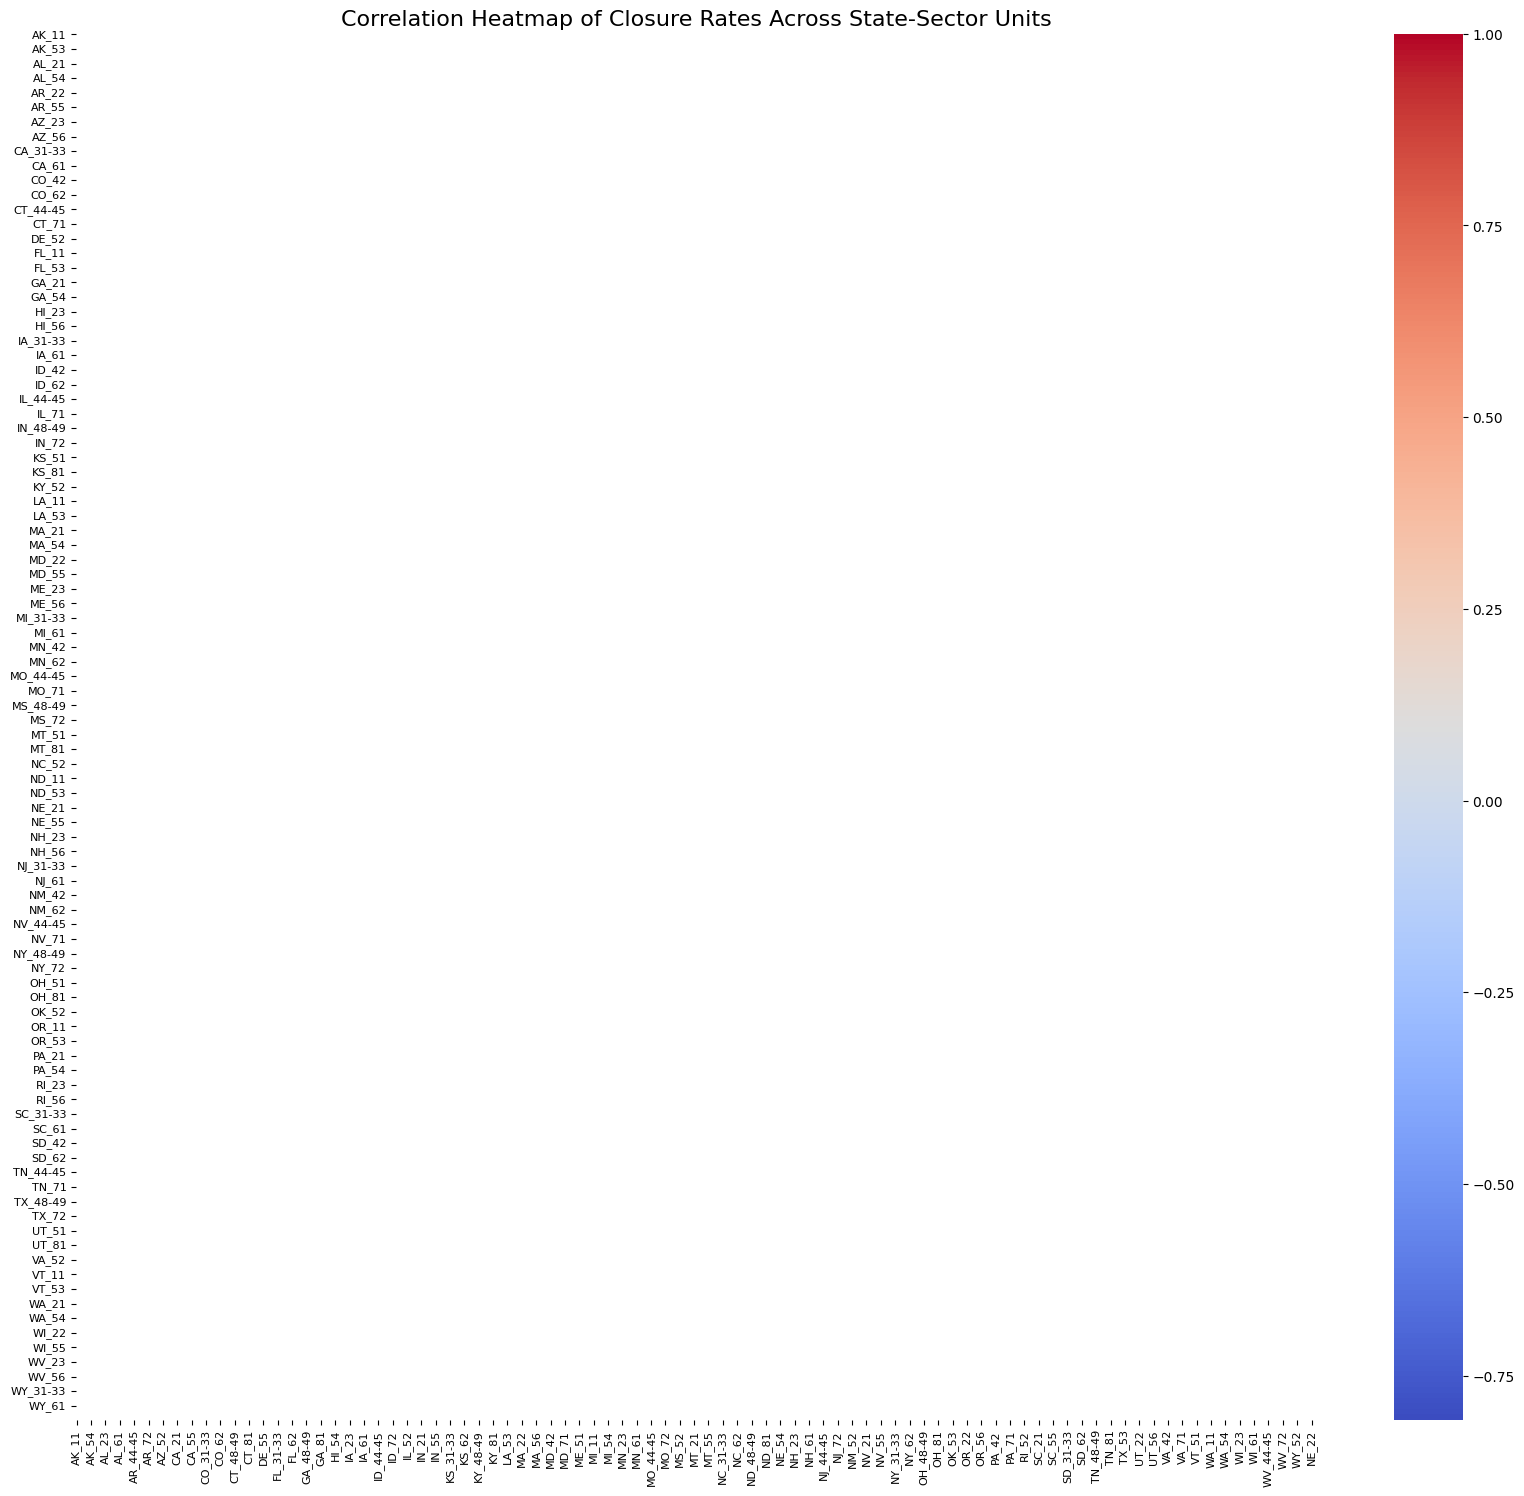

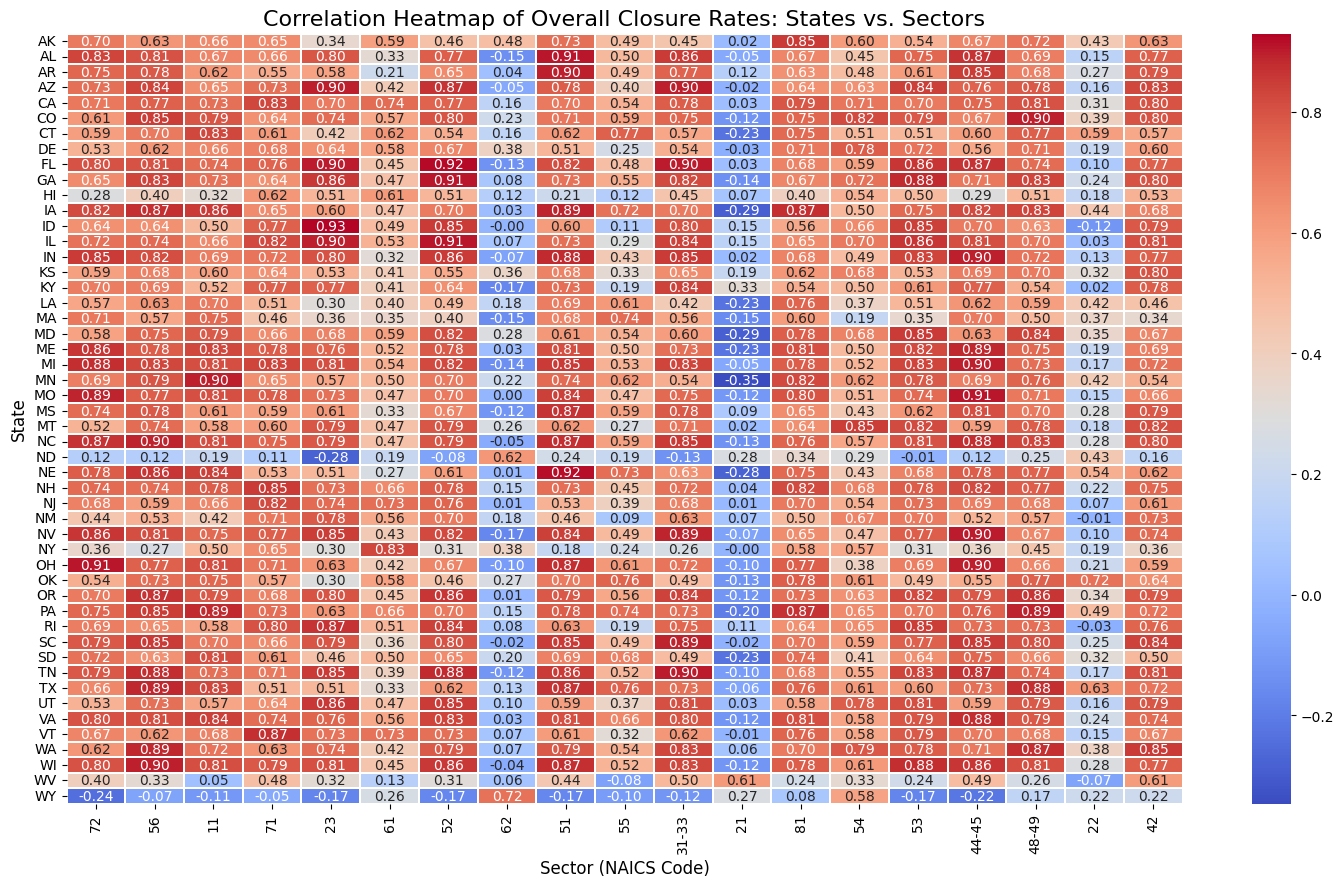

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a correlation heatmap for State-Sector Units
plt.figure(figsize=(20, 18)) # Adjusted for many units
sns.heatmap(corr_matrix_state_sector_units, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Closure Rates Across State-Sector Units', fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.show()

# Creating a correlation heatmap for State vs. Sector Overall Closure Rates
plt.figure(figsize=(18, 10)) # Adjusted for readability
sns.heatmap(corr_matrix_state_vs_sector.astype(float), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Overall Closure Rates: States vs. Sectors', fontsize=16)
plt.xlabel('Sector (NAICS Code)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()

### **Converting correlation matrix to embeddings (State-Sector Units)**

Converting the state-sector unit correlation matrix into lower-dimensional embeddings, where each (state, sector) unit becomes an 8-dimensional vector. This helps capture underlying relationships in a more compact form.

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Dimension for embeddings (consistent with previous models)
embedding_dim = 8

# Fill NaN values in the correlation matrix before SVD
corr_matrix_state_sector_units_cleaned = corr_matrix_state_sector_units.fillna(0)

# Getting Embeddings
svd_state_sector_units = TruncatedSVD(
    n_components=embedding_dim,
    random_state=42
)

state_sector_unit_embeddings = svd_state_sector_units.fit_transform(corr_matrix_state_sector_units_cleaned)

embedding_df_state_sector_units = pd.DataFrame(
    state_sector_unit_embeddings,
    index=corr_matrix_state_sector_units_cleaned.index # Use the cleaned index
)

embedding_df_state_sector_units.columns = [
    f"state_sector_emb_{i}"
    for i in range(embedding_dim)
]

print("State-Sector Unit Embeddings (first 5 rows):")
display(embedding_df_state_sector_units.head())

State-Sector Unit Embeddings (first 5 rows):


,state_sector_emb_0,state_sector_emb_1,state_sector_emb_2,state_sector_emb_3,state_sector_emb_4,state_sector_emb_5,state_sector_emb_6,state_sector_emb_7
AK_11,0.288074,-4.531499,5.784427,0.576952,-1.208565,-0.074141,-1.265206,-1.187733
AK_21,-0.468078,-0.937179,-3.224439,2.921558,3.070130,0.971187,0.207082,2.123416
AK_22,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AK_23,14.821527,-1.074486,-1.080277,0.854908,-1.069861,1.138909,1.431742,-0.225184
AK_31-33,4.004357,1.900568,-2.295754,0.664335,0.981592,2.587154,1.103304,0.208240


### **State-Sector Business Closure Co-occurrence Network**

This analysis visualizes the **co-movement of business closure rates between state-sector units** using a network graph. State-sector units are connected by an edge if their business closure rates exhibit a strong positive Pearson correlation (above a set threshold, currently 0.8).

*   **Edges:** Represent strong positive correlations between state-sector unit closure rates. The **thickness of the edge indicates the strength of this correlation**, with thicker edges signifying stronger co-movement.
*   **Nodes:** Represent individual (state, sector) units, labeled by `state_abbr_NAICS_code`. The **size of each unit's node reflects its total sum of firm deaths** over the years included in the analysis.
*   **Colors:** State-sector units are grouped and colored by detected communities, highlighting clusters of units that exhibit similar closure rate behaviors. Only the top 30 state-sector units (by total firm deaths) are included for visualization clarity.


Network Graph of State-Sector Unit Co-occurrence based on Closure Rate Correlation


/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:978: RuntimeWarning: invalid value encountered in divide
  displacement = compatibility * delta / distance_squared[..., None]
/usr/local/lib/python3.12/dist-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


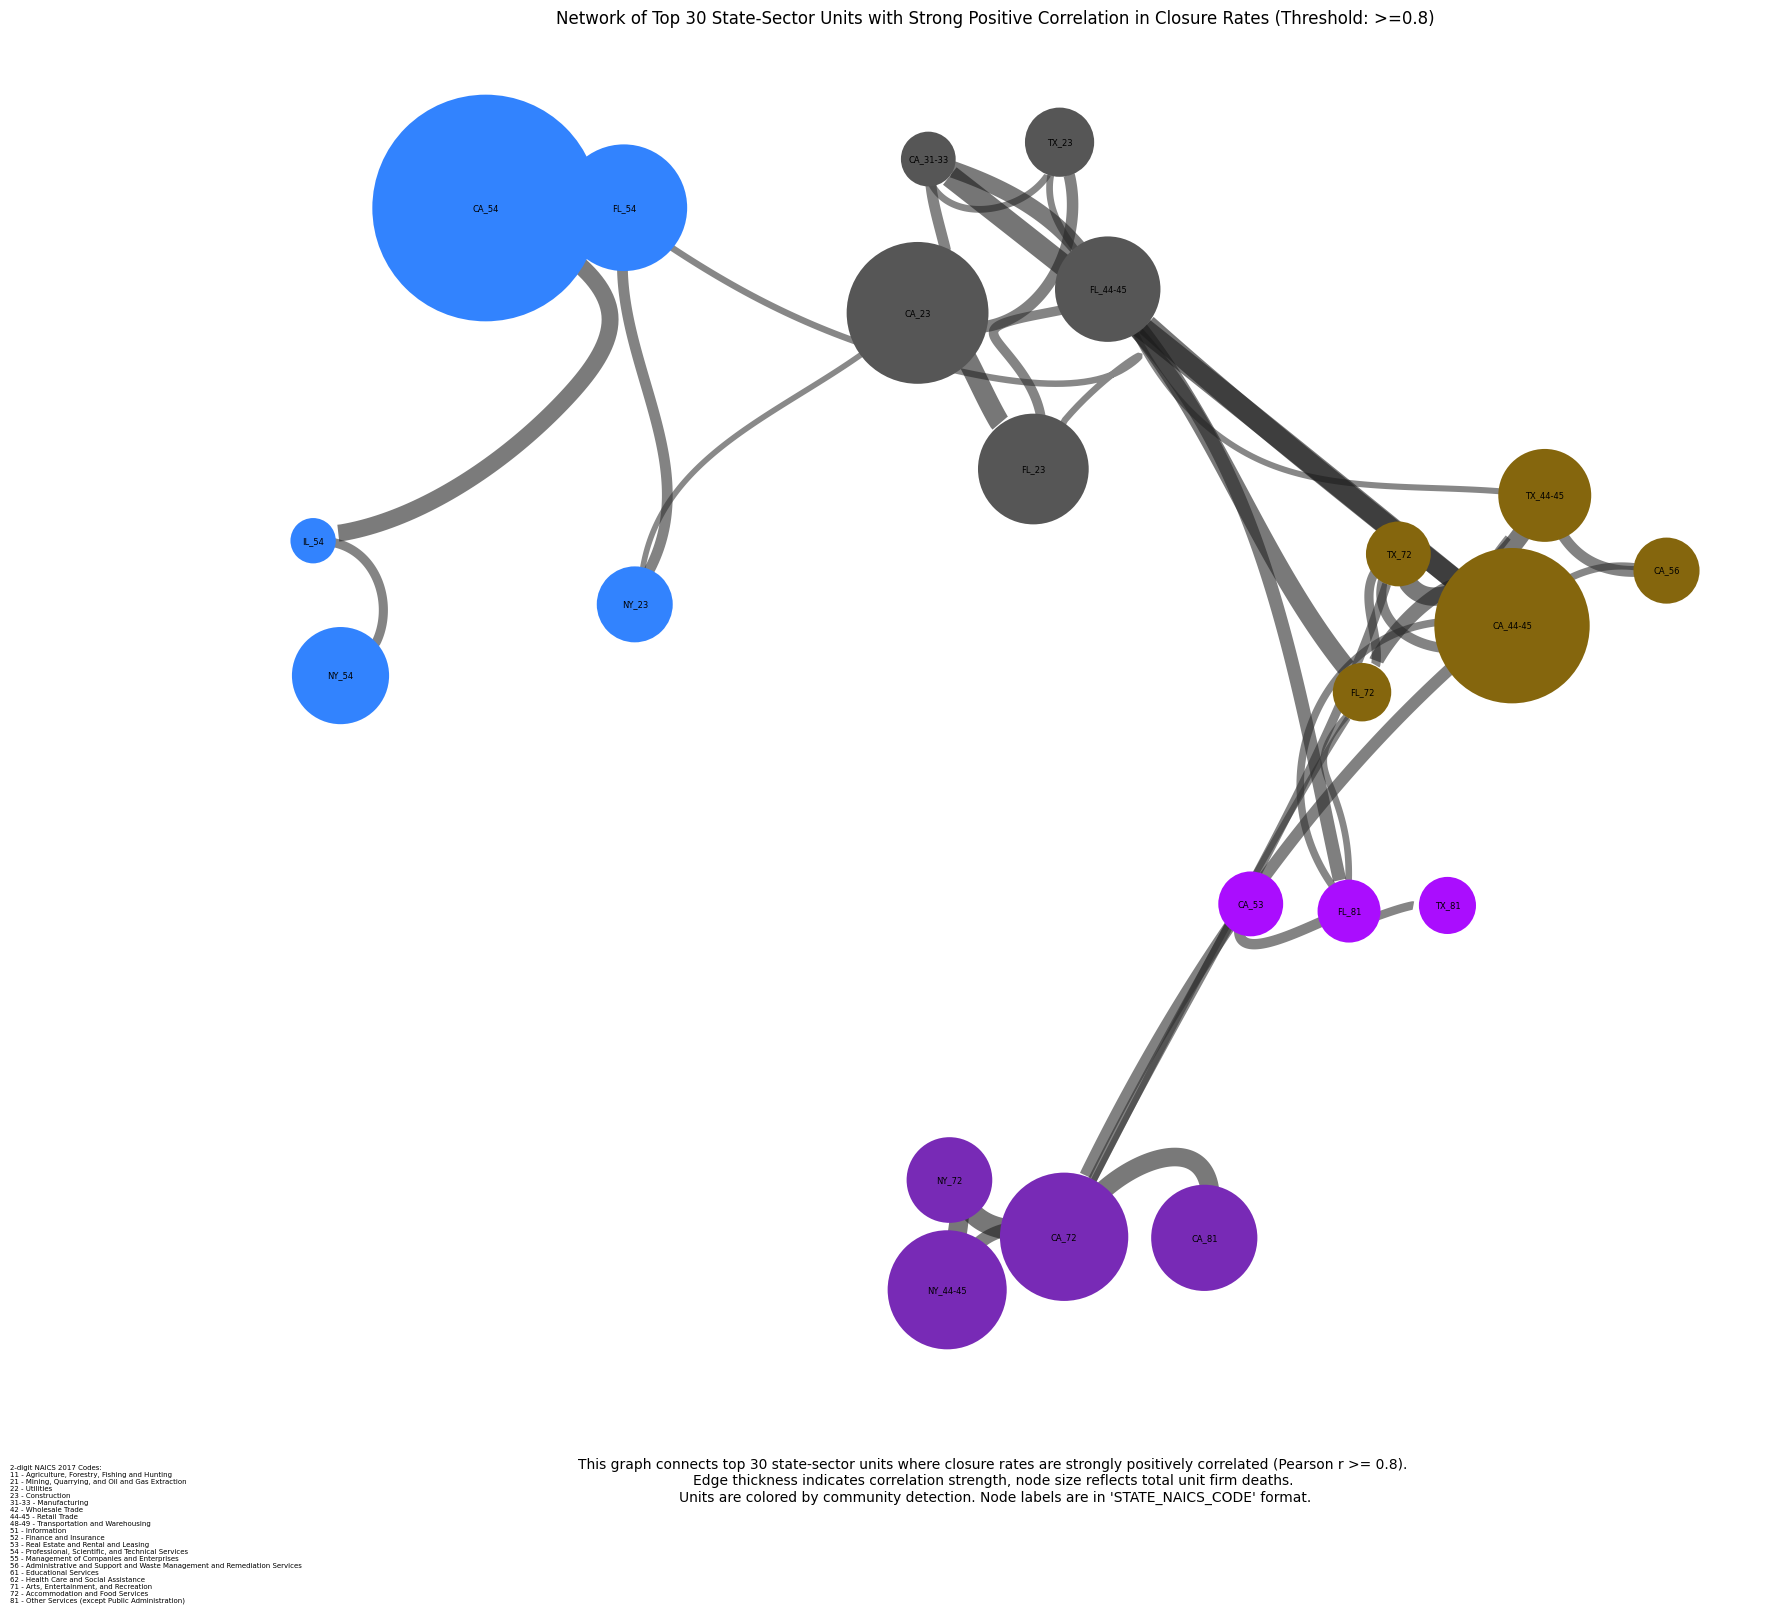

In [ ]:
import community.community_louvain as co
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from netgraph import Graph # Importing Graph from netgraph
import plotly.express as px

print("\nNetwork Graph of State-Sector Unit Co-occurrence based on Closure Rate Correlation")

# Define a correlation threshold for creating edges
correlation_threshold = 0.8 # Consistent with previous network graphs

# Calculate total firm deaths per state-sector unit for node sizing and filtering
state_sector_total_closures = df_with_naics.groupby(['state_abbr', 'naics_code'])['firmdeath_firms'].sum()
state_sector_total_closures.index = state_sector_total_closures.index.map(lambda x: f'{x[0]}_{x[1]}')

# Filter for top 30 state-sector units by total firm deaths
num_top_units = 30
top_units = state_sector_total_closures.nlargest(num_top_units).index.tolist()

# Create edges based on the state-sector unit correlation matrix, considering only top units
correlation_edges_state_sector_units = []

# Filter corr_matrix_state_sector_units to include only top units
filtered_corr_matrix_state_sector_units = corr_matrix_state_sector_units.loc[top_units, top_units]

for i in range(len(filtered_corr_matrix_state_sector_units.index)):
    for j in range(i + 1, len(filtered_corr_matrix_state_sector_units.columns)):
        unit1 = filtered_corr_matrix_state_sector_units.index[i]
        unit2 = filtered_corr_matrix_state_sector_units.columns[j]
        correlation_value = filtered_corr_matrix_state_sector_units.iloc[i, j]
        if correlation_value >= correlation_threshold: # Only consider strong positive correlations
            correlation_edges_state_sector_units.append({'u': unit1, 'v': unit2, 'weight': correlation_value})

# Creating the NetworkX graph
G_state_sector_units = nx.Graph()
for edge in correlation_edges_state_sector_units:
    G_state_sector_units.add_edge(edge['u'], edge['v'], weight=edge['weight'])

# Filtering out units that are not connected in the graph (isolates) within the top units
isolates_state_sector_units = list(nx.isolates(G_state_sector_units))
G_state_sector_units.remove_nodes_from(isolates_state_sector_units)

# Performing community detection
# Ensure there are nodes left after removing isolates before performing community detection
if G_state_sector_units.nodes():
    partition_state_sector_units = co.best_partition(G_state_sector_units)
    unique_communities_state_sector_units = sorted(list(set(partition_state_sector_units.values())))

    # Mapping nodes to communities for netgraph's community layout
    node_to_community_state_sector_units = partition_state_sector_units

    # Generating colors for communities
    community_colors_palette_state_sector_units = px.colors.qualitative.Alphabet
    community_color_map_state_sector_units = {
        community_id: community_colors_palette_state_sector_units[i % len(community_colors_palette_state_sector_units)]
        for i, community_id in enumerate(unique_communities_state_sector_units)
    }

    # Mapping each node to a color based on its community
    node_color_state_sector_units = {node: community_color_map_state_sector_units[partition_state_sector_units[node]] for node in G_state_sector_units.nodes()}
else:
    print("No connected state-sector units found above the correlation threshold.")
    partition_state_sector_units = {}
    node_to_community_state_sector_units = {}
    node_color_state_sector_units = {}


# Scaling node sizes for netgraph
# Filter state_sector_total_closures to only include units present in the graph
filtered_state_sector_total_closures = state_sector_total_closures[state_sector_total_closures.index.isin(G_state_sector_units.nodes())]

if not filtered_state_sector_total_closures.empty and len(G_state_sector_units.nodes()) > 0:
    min_closures_ss = filtered_state_sector_total_closures.min()
    max_closures_ss = filtered_state_sector_total_closures.max()

    if max_closures_ss == min_closures_ss:
        node_size_by_state_sector_units = {unit: 5 for unit in G_state_sector_units.nodes()}
    else:
        node_size_by_state_sector_units = {unit: 2 + 8 * (closures - min_closures_ss) / (max_closures_ss - min_closures_ss)
                                        for unit, closures in filtered_state_sector_total_closures.items()}
else:
    node_size_by_state_sector_units = {} # Empty if no nodes or no closure data

# Creating edge widths based on correlation strength for netgraph
edge_widths_state_sector_units = {}
for u, v, data in G_state_sector_units.edges(data=True):
    # Scale correlation values (0.7 to 1.0) to a reasonable width range (e.g., 0.5 to 3.0)
    correlation_value = data['weight']
    scaled_width = 0.5 + (correlation_value - correlation_threshold) * (2.5 / (1.0 - correlation_threshold))
    edge_widths_state_sector_units[(u,v)] = scaled_width

# Preparing node labels
node_labels_state_sector_units = {node: node for node in G_state_sector_units.nodes()} # Displaying state_abbr_NAICS_code as labels

fig_state_sector_units, ax_state_sector_units = plt.subplots(figsize=(20, 18)) # Adjusting figure size as needed

Graph(G_state_sector_units,
      node_color=node_color_state_sector_units, # Indicating the community each belongs to
      node_edge_width=0,     # Removing black border around nodes
      edge_width=edge_widths_state_sector_units,        # Using calculated edge widths
      edge_alpha=0.6,        # Setting alpha
      node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community_state_sector_units),
      node_size=node_size_by_state_sector_units, # Using the calculated node sizes
      node_labels=node_labels_state_sector_units,
      edge_layout='bundled',
      ax=ax_state_sector_units,
)

ax_state_sector_units.set_facecolor('white') # Setting the background to white

# Adding the title and explanation (static for netgraph)
ax_state_sector_units.set_title(f'Network of Top {num_top_units} State-Sector Units with Strong Positive Correlation in Closure Rates (Threshold: >={correlation_threshold})')
plt.text(0.5, -0.05,
         f"This graph connects top {num_top_units} state-sector units where closure rates are strongly positively correlated (Pearson r >= {correlation_threshold}). \nEdge thickness indicates correlation strength, node size reflects total unit firm deaths. \nUnits are colored by community detection. Node labels are in 'STATE_NAICS_CODE' format.",
         horizontalalignment='center',
         verticalalignment='center',
         transform=ax_state_sector_units.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Adding the NAICS legend below the main explanation for reference
naics_legend_text = "2-digit NAICS 2017 Codes:\n" + "\n".join([f"{code} - {name}" for code, name in naics_mapping.items()])
plt.figtext(0.02, 0.005, naics_legend_text, fontsize=5, ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()